In [4]:
!pip install ultralytics opencv-python tqdm pyyaml --quiet

In [7]:
import os
import torch
import yaml
from ultralytics import YOLO
from pathlib import Path

print("="*50)
print("ENVIRONMENT INFO")
print("="*50)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not enabled")

print("="*50)

ENVIRONMENT INFO
Torch version: 2.10.0+cpu
CUDA available: False


In [ ]:
BASE_DIR = Path("/content")

DATASET_DIR = BASE_DIR / "dataset"

TRAIN_IMAGES = DATASET_DIR / "images/train"
VAL_IMAGES = DATASET_DIR / "images/val"

TRAIN_LABELS = DATASET_DIR / "labels/train"
VAL_LABELS = DATASET_DIR / "labels/val"

PROJECT_DIR = BASE_DIR / "amr_training"

PROJECT_DIR.mkdir(exist_ok=True)

print("Dataset dir:", DATASET_DIR)
print("Project dir:", PROJECT_DIR)

Dataset dir: /content/dataset
Project dir: /content/amr_training


In [ ]:
import os
from pathlib import Path

# Base dataset directory
BASE_DIR = Path("/content/dataset")

# Required YOLO folder structure
folders = [
    BASE_DIR / "images/train",
    BASE_DIR / "images/val",
    BASE_DIR / "labels/train",
    BASE_DIR / "labels/val"
]

# Create folders
for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Created: {folder}")

print("\nDataset folder structure ready!")

# Show structure
print("\nFinal structure:")
for root, dirs, files in os.walk(BASE_DIR):
    print(root)

Created: /content/dataset/images/train
Created: /content/dataset/images/val
Created: /content/dataset/labels/train
Created: /content/dataset/labels/val

Dataset folder structure ready!

Final structure:
/content/dataset
/content/dataset/labels
/content/dataset/labels/train
/content/dataset/labels/val
/content/dataset/images
/content/dataset/images/train
/content/dataset/images/val


In [ ]:
import os
from pathlib import Path
from collections import Counter

# Root dataset path (change if needed)
DATASET_PATH = Path("/content/dataset")

IMAGE_EXT = (".jpg", ".jpeg", ".png")

def verify_split(split):
    print(f"\n===== Checking {split.upper()} split =====")

    image_dir = DATASET_PATH / "images" / split
    label_dir = DATASET_PATH / "labels" / split

    images = sorted([f for f in image_dir.glob("*") if f.suffix.lower() in IMAGE_EXT])
    labels = sorted(label_dir.glob("*.txt"))

    image_names = set(f.stem for f in images)
    label_names = set(f.stem for f in labels)

    print(f"Total Images : {len(images)}")
    print(f"Total Labels : {len(labels)}")

    # Missing labels
    missing_labels = image_names - label_names
    if missing_labels:
        print(f"\n❌ Missing labels for {len(missing_labels)} images:")
        print(list(missing_labels)[:10])
    else:
        print("\n✅ All images have labels")

    # Missing images
    missing_images = label_names - image_names
    if missing_images:
        print(f"\n❌ Missing images for {len(missing_images)} labels:")
        print(list(missing_images)[:10])
    else:
        print("✅ All labels have images")

    return images, labels


def check_label_integrity(split):
    print(f"\n===== Checking Label Integrity: {split.upper()} =====")

    label_dir = DATASET_PATH / "labels" / split

    class_counter = Counter()
    corrupt_files = []

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            # YOLO format must have 5 values
            if len(parts) != 5:
                corrupt_files.append(label_file.name)
                continue

            class_id = int(parts[0])
            class_counter[class_id] += 1

    print("\nClass distribution:")
    for cls, count in sorted(class_counter.items()):
        print(f"Class {cls}: {count} objects")

    if corrupt_files:
        print(f"\n❌ Corrupt label files: {len(corrupt_files)}")
        print(corrupt_files[:10])
    else:
        print("\n✅ All labels valid")

    return class_counter


# Run verification
train_images, train_labels = verify_split("train")
val_images, val_labels = verify_split("val")

train_classes = check_label_integrity("train")
val_classes = check_label_integrity("val")

# Final summary
print("\n========== FINAL SUMMARY ==========")
print(f"Train Images: {len(train_images)}")
print(f"Train Labels: {len(train_labels)}")
print(f"Val Images: {len(val_images)}")
print(f"Val Labels: {len(val_labels)}")

total_images = len(train_images) + len(val_images)
train_ratio = len(train_images) / total_images * 100
val_ratio = len(val_images) / total_images * 100

print(f"\nTrain Ratio: {train_ratio:.2f}%")
print(f"Val Ratio: {val_ratio:.2f}%")

print("\nDataset verification complete ✅")


===== Checking TRAIN split =====
Total Images : 144
Total Labels : 144

✅ All images have labels
✅ All labels have images

===== Checking VAL split =====
Total Images : 47
Total Labels : 47

✅ All images have labels
✅ All labels have images

===== Checking Label Integrity: TRAIN =====

Class distribution:
Class 0: 239 objects

✅ All labels valid

===== Checking Label Integrity: VAL =====

Class distribution:
Class 0: 96 objects

✅ All labels valid

========== FINAL SUMMARY ==========
Train Images: 144
Train Labels: 144
Val Images: 47
Val Labels: 47

Train Ratio: 75.39%
Val Ratio: 24.61%

Dataset verification complete ✅


In [ ]:
import yaml
from pathlib import Path

DATASET_PATH = Path("/content/dataset")

data_yaml = {
    "path": str(DATASET_PATH),
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "AMR"
    }
}

with open("/content/dataset/data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created")

data.yaml created


In [ ]:
model = YOLO("yolov8s.pt")  # start with nano

model.train(
    data="/content/dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    workers=2,
    project="/content",
    name="amr_training",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    patience=50,
    save=True,
    device=0
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=amr_training2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=50, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5ddf79e3f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
model = YOLO("/content/amr_training2/weights/best.pt")

metrics = model.val()
print(metrics)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2079.5±704.7 MB/s, size: 311.5 KB)
val: Scanning /content/dataset/labels/val.cache... 47 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 15.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.0s/it 3.0s
                   all         47         96      0.979      0.969      0.971      0.844
Speed: 9.5ms preprocess, 18.7ms inference, 0.0ms loss, 5.9ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5cc532dc10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/amr_training2/weights/best.pt")

print("Model loaded successfully")

Model loaded successfully


In [ ]:
results = model.predict(
    source="/content/Test/Media1.jpg",  # change to your image
    conf=0.25,
    save=True,
    show=False
)

print("Detection complete")


image 1/1 /content/Test/Media1.jpg: 640x480 (no detections), 12.1ms
Speed: 3.0ms preprocess, 12.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Detection complete


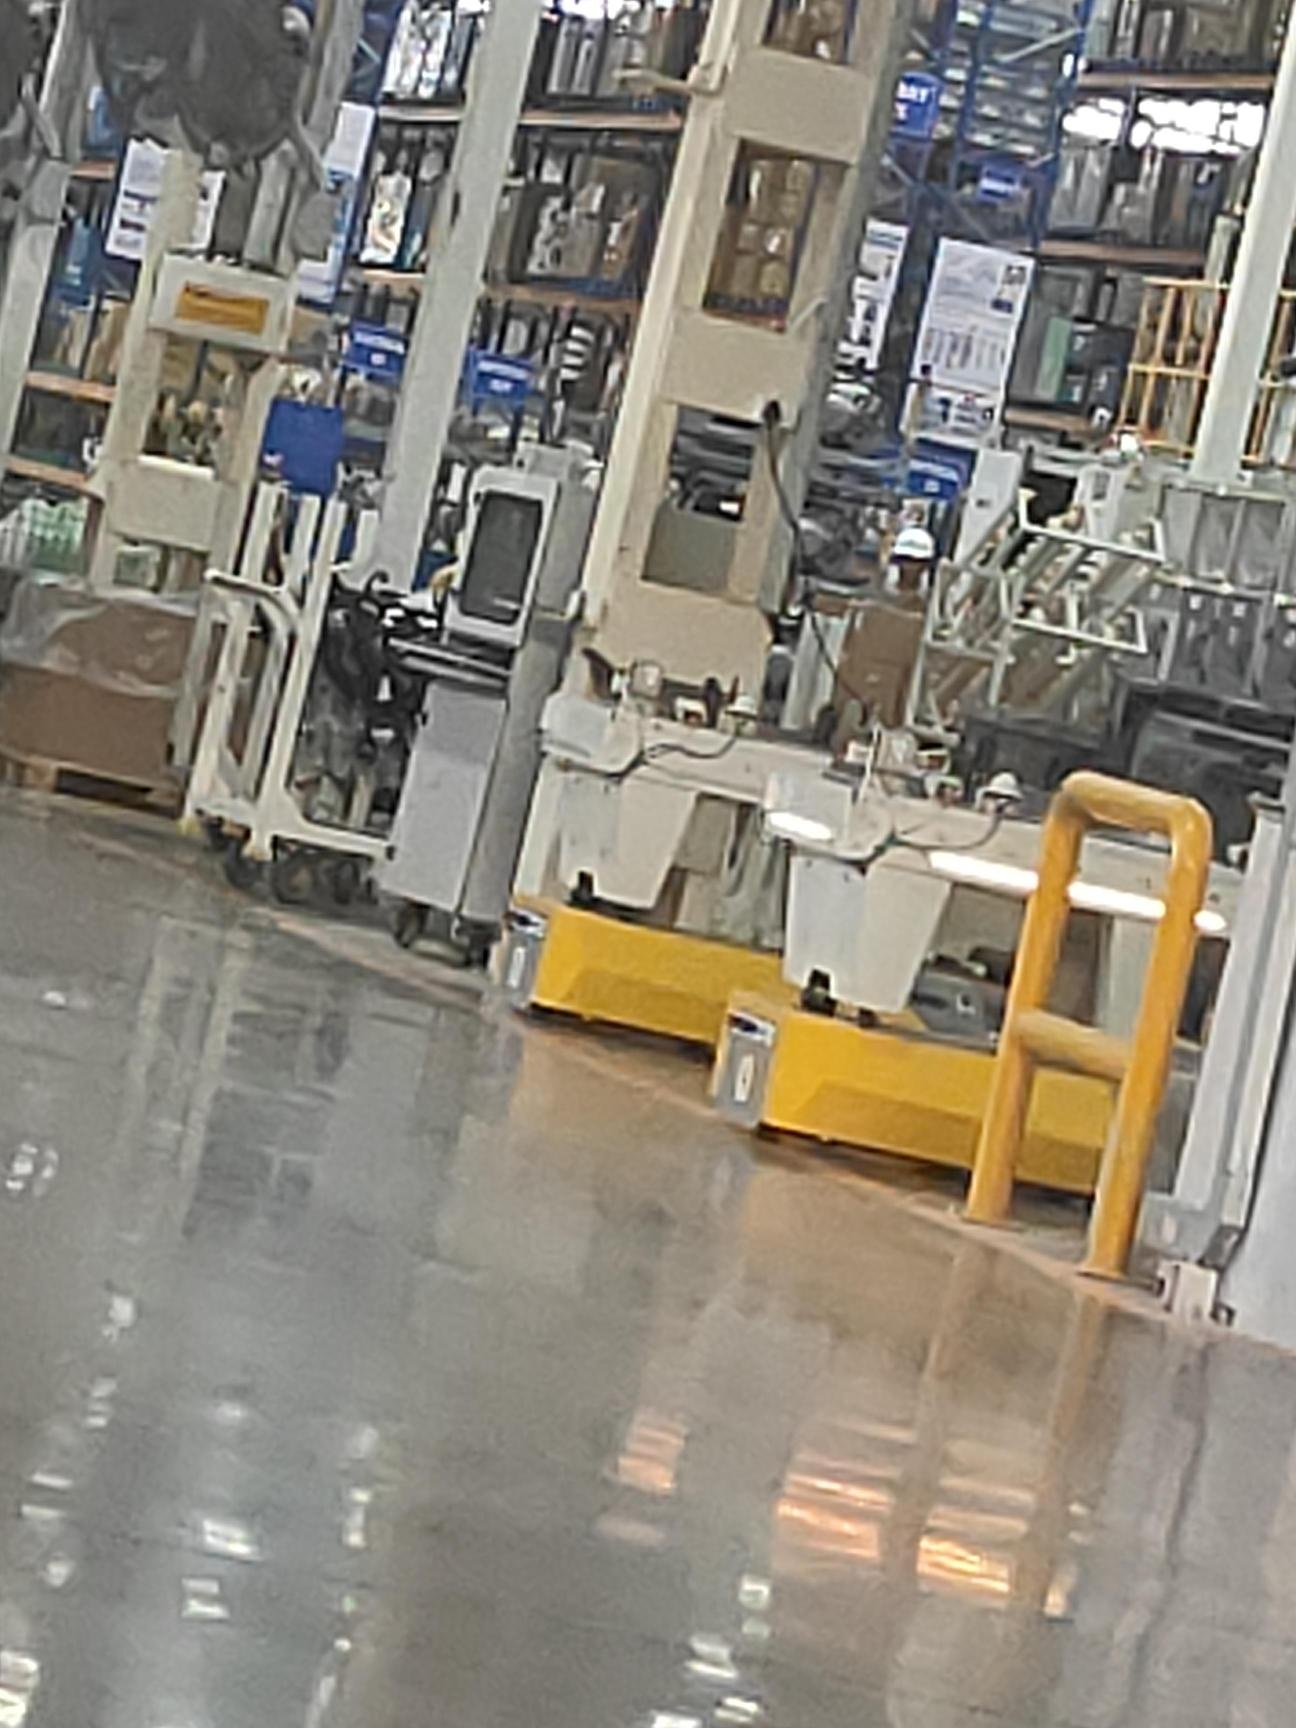

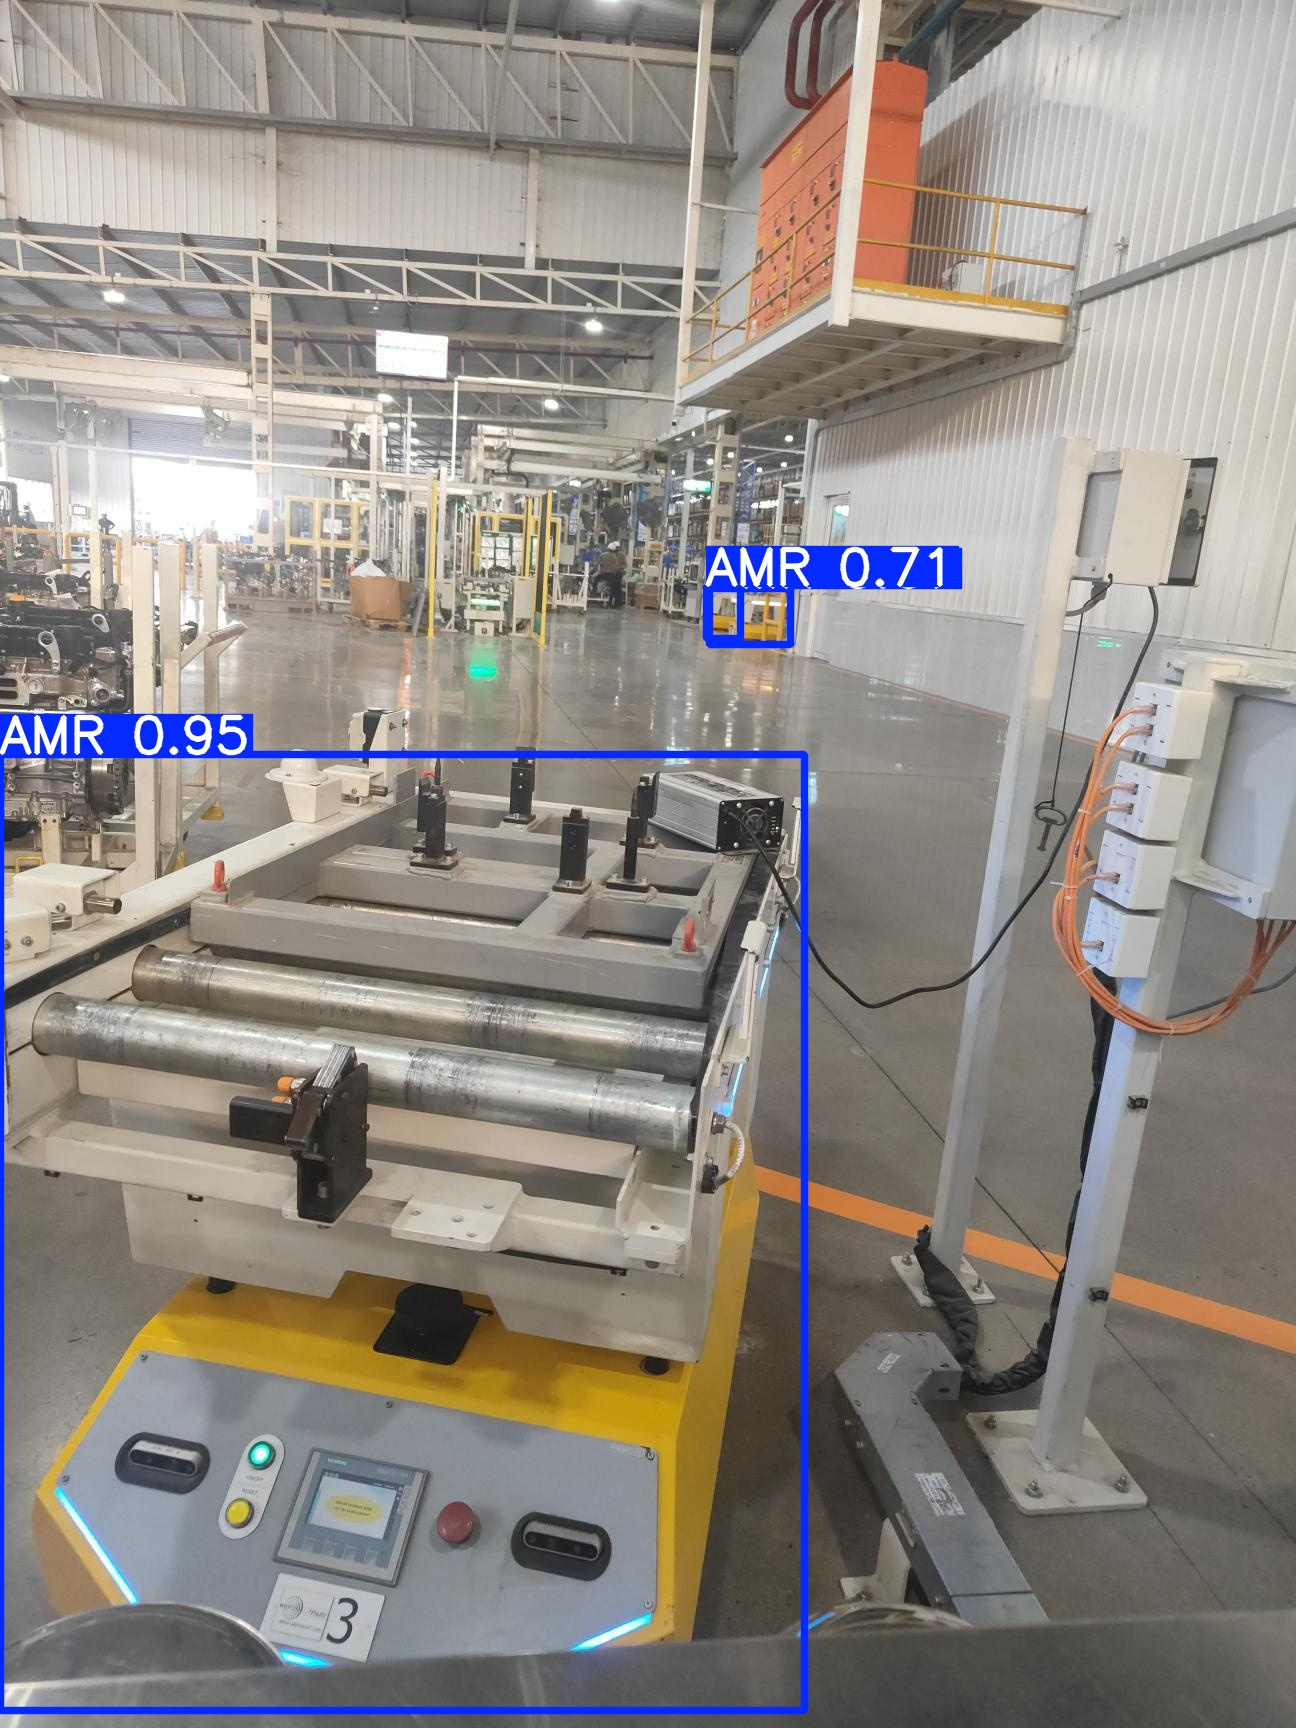

In [ ]:
from IPython.display import Image, display
import os

output_folder = "/content/runs/detect/predict"

files = os.listdir(output_folder)

for file in files:
    if file.endswith(".jpg") or file.endswith(".png"):
        display(Image(os.path.join(output_folder, file)))

In [ ]:
results = model.predict(
    source="/content/Test_video/AMR_video.mp4",  # your video path
    conf=0.5,                           # confidence threshold
    save=True,                          # saves output video
    show=False,
    stream=False
)

print("Processing complete")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/250) /content/Test_video/AMR_video.mp4: 640x384 1 AMR, 46.8ms
video 1/1 (frame 2/250) /content/Test_video/AMR_video.mp4: 640x384 2 AMRs, 10.6ms
video 1/1 (frame 3/250) /content/Test_video/AMR_video.mp4: 640x384 2 AMRs, 10.6ms
video 1/1 (frame 4/250) /content/Test_video/AMR_video.mp4: 640x384 2 AMRs, 11.0ms
video 1/1 (frame 5/250) /content/Test_video/AMR_video.mp4: 640x384 2 AMRs, 10.6ms
video 1/1 (frame 6/250) /content/Test_video/AMR_v

In [ ]:
from IPython.display import HTML
from base64 import b64encode

video_path = "/content/runs/detect/predict/AMR_video.avi"

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=600 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
import cv2
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/amr_training2/weights/best.pt")

# Mobile camera stream URL
stream_url = "http://100.92.90.214:8080/video"

cap = cv2.VideoCapture(stream_url)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Detect AMR
    results = model(frame, conf=0.5)

    annotated_frame = results[0].plot()

    # Show result
    cv2.imshow("AMR Detection", annotated_frame)

    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()